# Deprojecting an MGE model

We want to know the deprojected density model from the MGE fit performed to the galaxy surface brightness. For this I will start with the axisymmetric case and use the equations in Capellari+2022

In [2]:
import matplotlib.pyplot as plt
import os
import sys
sys.path.append('/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/scripts/mge_class')
from mge_gen2 import MGEFitter
from astropy.io import fits
import numpy as np



# Load the MGE fit

Found 79853441 NaN pixels in the image. Replacing with 0 and adding to dust mask.
Sky level: 0.5486 +- 0.019
Sky sigma: 0.1669 +- 0.017
Sky mean: 0.549  Sky sigma: 0.167  Setting minlevel to 0.083
 Pixels used: 5470391
 Peak img[j, k]: 7392, 7522
 Mean (j, k): 7412.01 7533.48
 Theta (deg): 0.8
 Astro PA (deg): 89.2
 Eps: 0.751
 Major axis (pix): 2979.6
Found galaxy center at public (x, y) = (7522.00, 7392.00), PA=89.17 deg, eps=0.751, theta=0.83 deg
Sky mean: 0.549  Sky sigma: 0.167


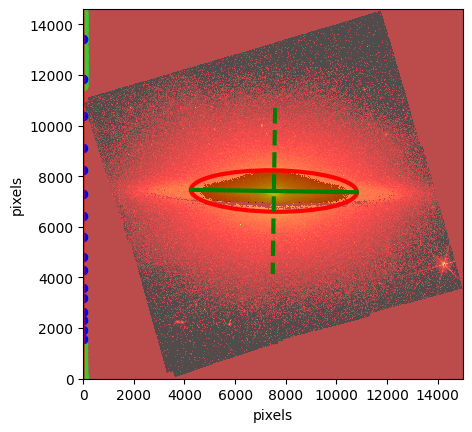

In [5]:

img_f200 = fits.open(
    '/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/IFU/photometry/f200w_ifu_coadd_masked.fits'
)[0].data

dust_mask = fits.open(
    '/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/dust_mask/f200_mask_1.fits'
)[0].data

nan_mask = np.isnan(img_f200)
if np.any(nan_mask):
    print(f"Found {np.sum(nan_mask)} NaN pixels in the image. Replacing with 0 and adding to dust mask.")
    img_f200[nan_mask] = 0.0
    dust_mask = dust_mask | nan_mask

checkplot_dir = "/Users/mncavieres/Documents/2026-1/Sombrero_REVEAL/Data/mge_test_nosky_0deg_pa_positive_gauss"
#_ensure_dir(checkplot_dir)

runner = MGEFitter(
    img_f200,
    dust_mask,
    pixel_scale=0.031,
    subtract_sky=True,
    linear=False,
    ngauss=30,
    plot=True,
    checkplot_dir=checkplot_dir,
    cache_dir=checkplot_dir,
    prefix="sombrero_f200",
    contour_half_size_arcsec=80,
    contour_oversample=1,
    n_sectors=19,
    allow_negative=False,
    bulge_disk=False,
)

# x_peak, y_peak = brightest_pixel_near(
#     img_f200, 7538, 7333, halfsize=40, goodmask=runner.goodmask
# )

# print(f"Initial guess for galaxy center (x, y) [pix]: ({x_peak:.2f}, {y_peak:.2f})")
# print(f"Pixel value at center img[y, x] = img[{int(round(y_peak))}, {int(round(x_peak))}] = "
#         f"{img_f200[int(round(y_peak)), int(round(x_peak))]}")

# runner.set_manual_geometry(
#     center=(x_peak, y_peak),   # correct public convention: (x, y)
#     pa_deg=0,#90.78185872429874,#87.2,
#     eps=0.7060956459920877, #0.35,
#     theta_deg=90.78185872429874,#87.2,
# )

#print(f"Stored manual center in runner: (x, y) = ({runner.xc:.2f}, {runner.yc:.2f})")

# remember to set things to force=True if you want to re-run steps that have already been cached
#runner.run_sectors()  # this will use the new geometry and overwrite any previous sectors
runner.run_fit() # 

In [12]:
results = runner.results_dict()

In [13]:
results

{'center_pix': (7538.0, 7332.0),
 'pa_deg': 0.0,
 'eps': 0.7060956459920877,
 'theta_deg': 90.78185872429874,
 'manual_geometry': True,
 'sky_mean': 0.5485691746524846,
 'sky_sigma': 0.16688449085665336,
 'find_result': None,
 'sectors': <mgefit.sectors_photometry.sectors_photometry at 0x7fd480129d30>,
 'mgefit': <mgefit.mge_fit_sectors.mge_fit_sectors at 0x7fd480115a90>,
 'table_cols': ['surf_counts_per_pix',
  'sigma_pix',
  'sigma_arcsec',
  'q_obs',
  'total_counts'],
 'table': array([[6.51028805e+02, 3.94956666e+00, 1.22436566e-01, 7.07907678e-01,
         4.51705721e+04],
        [1.86442009e+02, 8.52622475e+00, 2.64312967e-01, 6.78460815e-02,
         5.77779281e+03],
        [9.05328516e+02, 1.05235769e+01, 3.26230883e-01, 5.95315276e-01,
         3.75024682e+05],
        [4.32280135e+02, 2.57931152e+01, 7.99586571e-01, 5.07031210e-01,
         9.16193982e+05],
        [2.79440576e+02, 3.91663654e+01, 1.21415733e+00, 6.81151974e-01,
         1.83459370e+06],
        [2.90183788

In [14]:
def axisymmetric_deprojection(res, inclination):
    """
    Perform axisymmetric deprojection of the MGE model to get the 3D luminosity density profile.
    
    Parameters:
    - res: dictionary containing MGE fit results, including 'Sigma0', 'sigma_arcsec', and 'q'.
    - inclination: inclination angle in degrees (0 = face-on, 90 = edge-on).
    
    Returns the deprojected gaussians using the formula from Cappellari (2002) for axisymmetric deprojection.
    """

    # get the MGE parameters from the results dictionary
    # the table has columns 'surf_counts_per_pix','sigma_pix','sigma_arcsec','q_obs','total_counts'
    table = res["table"]

    # deproject the q which is the 3rd column (index 3) using the formula for axisymmetric deprojection
    q_obs = table[:, 3]
     # this is the formula for deprojecting the observed axial ratio to get the intrinsic axial ratio for an axisymmetric model
    q_deproj = np.sqrt(q_obs**2 - np.cos(np.radians(inclination))**2) / np.sin(np.radians(inclination))
    
    # compute the intrinsic surface brightness for each Gaussian using the observed surface brightness and the deprojected axial ratio
    Ijp = table[:, 0]  # this is the observed central surface brightness
    sigma_arcsec = table[:, 2]  # this is the sigma in arcseconds
    Ij = Ijp * q_obs /(q_deproj * sigma_arcsec*np.sqrt(2*np.pi))  # this is the formula for the intrinsic surface brightness of each Gaussian after deprojection

    # the deprojected sigma is the same as the observed sigma since we are assuming axisymmetry and the same scale height in the vertical direction
    return Ij, sigma_arcsec, q_deproj


    

In [15]:
Ij, sigma_arcsec, q_deproj = axisymmetric_deprojection(results, inclination=87.2)

In [18]:
def build_deproject_density_map(Ij, sigma_arcsec, q_deproj, grid_size=100, grid_extent=10):
    """
    Build the deprojected 3D luminosity density map from the deprojected MGE parameters.
    
    Parameters:
    - Ij: array of intrinsic surface brightnesses for each Gaussian component.
    - sigma_arcsec: array of sigma values in arcseconds for each Gaussian component.
    - q_deproj: array of deprojected axial ratios for each Gaussian component.
    
    Returns a 3D array representing the luminosity density map.
    """
    # This function would involve creating a 3D grid and summing the contributions from each Gaussian component
    # build a grid in cylindrical coordinates (R, z) and compute the luminosity density at each point by summing over the contributions from each Gaussian
    grid_R = np.linspace(0, grid_extent, grid_size)
    grid_z = np.linspace(-grid_extent, grid_extent, grid_size)
    density_map = np.zeros((grid_size, grid_size))

    # loop over each Gaussian component and add its contribution to the density map
    for I, sigma, q in zip(Ij, sigma_arcsec, q_deproj):
        # compute the contribution of this Gaussian to the density map
        # the formula for the luminosity density of a Gaussian in cylindrical coordinates would depend on the deprojected parameters
        # this is a placeholder for the actual formula which would need to be derived from the MGE model
        contribution = I * np.exp(-0.5 * (grid_R**2 / sigma**2 + grid_z**2 / (sigma*q)**2))
        density_map += contribution
    return density_map